## Import

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import scipy.linalg as linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
#import preprocess


device = 'cuda:1'

%load_ext autoreload
%autoreload 2

## Data generation

In [2]:
from datasets import Spiral

n, d = 10000, 64                                
true_rho = 0.7                                   # < higher rho, higher MI
v = 3.14/2

dataset = Spiral.Spiral(rho=true_rho, dim=d, v=v)
X, Y = dataset.sample(n=10000)
X, Y = X.to(device).clone().detach(), Y.to(device).clone().detach()


print('X size=', X.size(), 'Y size=', Y.size())
print("True MI is", dataset.MI())

X size= torch.Size([10000, 32]) Y size= torch.Size([10000, 32])
True MI is 10.773512852220248


## Train the VCE estimator

In [3]:
class Hyperparams(object):
    def __init__(self): 
        self.critic = 'neural'                # ('neural', 'quadratic')
        self.lr = 5e-4
        self.bs = 500
        self.n_bridges = 4
        self.wd = 1e-5
        self.max_iteration = 1250
        
hyperparams=Hyperparams()

architecture_critic = [d, 500, 500, 500, 1]

In [4]:
## Neural adaptive MI estimate
from estimators.VCE import VCE

estimator = VCE(None, None, architecture_critic, hyperparams)
estimator.to(device)
estimator.learn(X, Y)

print('true MI:', dataset.MI())
print('est MI:', estimator.MI(X, Y))

K components= 5 copula transform= True
nde type: FM
finished: t= 0 loss= 1.9900588989257812 loss val= 2.0123703479766846 best val loss= 2.0123703479766846 best t= 0
finished: t= 126 loss= 1.590926170349121 loss val= 1.6379127502441406 best val loss= 1.596588373184204 best t= 82
finished: t= 252 loss= 1.623189091682434 loss val= 1.6287308931350708 best val loss= 1.596588373184204 best t= 82


finished: t= 0 loss= 1.9649407863616943 loss val= 1.9996850490570068 best val loss= 1.9996850490570068 best t= 0
finished: t= 126 loss= 1.655781865119934 loss val= 1.629259705543518 best val loss= 1.6025514602661133 best t= 47


finished: t= 0 loss= 447.5946960449219 loss val= 450.72711181640625 best val loss= 450.72711181640625 best t= 0
finished: t= 101 loss= 80.25579833984375 loss val= 80.60249328613281 best val loss= 80.58428955078125 best t= 99
finished: t= 202 loss= 80.18291473388672 loss val= 80.6077880859375 best val loss= 80.58428955078125 best t= 99


K components= 5 finished
true MI: 10.

### Check the computed vector ranks

In [5]:
import torch.distributions as distribution

XX, YY = estimator.forward(X, Y)

# Compute empirical ranks
sorted_data, idx = torch.sort(XX, dim=0)
_, idx2 = torch.sort(idx, dim=0)
U = (idx2.float()+1)/(len(XX)+1)   

# Compute covariance
zeros, ones = torch.zeros(XX.size()).to(XX.device), torch.ones(XX.size()).to(XX.device)
U = (U-U.mean(keepdim=True, dim=0))/U.std(keepdim=True, dim=0)


V = torch.matmul(U.t(), U)/(len(U)+1)

### Visualizing the distributions of non-diagonal elements

mean abs 0.018293430752686333
q5 -0.028867101296782494
q95 0.029543716460466385


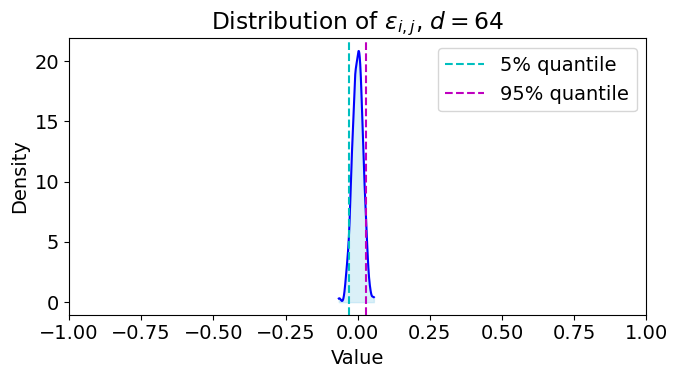

In [6]:
from scipy.stats import gaussian_kde

# Set global font size
plt.rcParams.update({'font.size': 14})

# Get non-diagonal elements of covariance matrices
non_diag_mask = ~torch.eye(V.size(0), dtype=bool, device=V.device)
non_diag_values = V[non_diag_mask]

# Convert to numpy
non_diag_np = non_diag_values.cpu().numpy()
sorted_vals = np.sort(non_diag_np)

# Compute ranks
L = len(sorted_vals)
q5, q95 = sorted_vals[int(L * 0.05)], sorted_vals[int(L * 0.95)]
print('mean abs', (sorted_vals**2).mean()**0.5)
print('q5', q5.item())
print('q95', q95.item())

# KDE with scipy
kde = gaussian_kde(non_diag_np)
x_vals = np.linspace(min(non_diag_np), max(non_diag_np), 1000)
density = kde(x_vals)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(x_vals, density, color='blue')
plt.fill_between(x_vals, density, alpha=0.3, color='skyblue')
plt.axvline(q5, color='c', linestyle='--', label='5% quantile')
plt.axvline(q95, color='m', linestyle='--', label='95% quantile')
plt.title(r'Distribution of $\epsilon_{i, j}$, $d=64$')
plt.xlim(-1, 1)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('vector_rank_quality_Spiral_64D.png', dpi=300)
plt.show()